# CIK Behavior Analysis

Profile every institutional investor (CIK) across all quarters in `normalized_holdings`, compute behavioral metrics, and produce a tunable filter that returns the CIKs matching user-defined thresholds.

**Metrics computed per CIK (aggregated over all quarters they appear):**

| Group | Metric | Meaning |
|---|---|---|
| Activity | `n_quarters` | quarters the CIK files |
| Activity | `first_quarter`, `last_quarter` | lifespan |
| Size | `aum_mean`, `aum_median` | avg portfolio USD value |
| Size | `aum_log_std` | volatility of log(AUM) qoq |
| Size | `aum_cagr` | AUM growth rate first→last |
| Breadth | `n_holdings_mean`, `n_holdings_std` | number of positions |
| Concentration | `hhi_mean` | Σ wᵢ² — 1 = single stock, 1/N = uniform |
| Concentration | `top5_weight_mean` | share in top-5 holdings |
| Turnover | `turnover_mean` | ½·Σ|Δwᵢ| per quarter (paper definition) |
| Turnover | `turnover_std` | stability of turnover |
| Churn | `open_rate_mean` | fraction of positions newly opened each qtr |
| Churn | `close_rate_mean` | fraction fully closed each qtr |
| Churn | `avg_holding_duration` | mean # quarters a position is held |

Use the **Filter** cell near the bottom to set thresholds and retrieve CIK lists.

## Setup

In [34]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

warnings.filterwarnings("ignore", category=UserWarning)

for env_path in [Path.cwd() / ".env", Path.cwd().parent / ".env", Path.cwd().parent.parent / ".env"]:
    if env_path.exists():
        load_dotenv(env_path)
        print("Loaded .env from:", env_path.resolve())
        break

def project_root() -> Path:
    """Walk up the directory tree until we find the folder containing ETL/."""
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "ETL").is_dir():
            return p
    raise FileNotFoundError(
        f"could not locate project root (folder containing ETL/) "
        f"starting from {cwd}"
    )

ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("project root:", ROOT)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

# Locate the existing cache regardless of the notebook's cwd. Jupyter may
# launch from the project root, the notebook's own dir, or anywhere in
# between — so we search likely places before falling back to ./cache.
def _find_cache_dir() -> Path:
    sentinel = "quarter_stats.parquet"
    here = Path.cwd().resolve()
    candidates = [
        here / "cache",
        here.parent / "cache",
        ROOT / "SocialNetwork" / "src" / "Korkevados" / "cache",
        ROOT / "cache",
    ]
    for c in candidates:
        if (c / sentinel).exists():
            return c.resolve()
    # No cache found — default to the notebook's own cache/ folder.
    default = here / "cache"
    default.mkdir(parents=True, exist_ok=True)
    return default

CACHE = _find_cache_dir()
print("cache dir:", CACHE)
REFRESH = False  # set True to repull from DB

# Cache files used by the next cells
qstats_pq   = CACHE / "quarter_stats.parquet"
aum_pq      = CACHE / "aum.parquet"
churn_pq    = CACHE / "churn.parquet"
duration_pq = CACHE / "duration.parquet"

# Connect to Postgres only when we actually need to repull.
# The ETL.data_handlers.db_data_handler package was relocated and the
# DB connector can't import its dependency right now, so we keep this
# lazy and skip it whenever the parquet caches already exist.
need_db = REFRESH or not all(p.exists() for p in
                             (qstats_pq, aum_pq, churn_pq, duration_pq))

handler = None
TARGET_DB = TGT_NORMALIZED_HOLDINGS = TGT_CIK_AUM = None
if need_db:
    try:
        from ETL.gnn_db_pipeline.config import (
            TARGET_DB, TGT_NORMALIZED_HOLDINGS, TGT_CIK_AUM,
        )
        from ETL.gnn_db_pipeline.db_connector import ConfigurablePostgresHandler
        handler = ConfigurablePostgresHandler(TARGET_DB)
        handler.connect()
        print("Connected to", TARGET_DB)
    except ModuleNotFoundError as e:
        raise ModuleNotFoundError(
            f"Cache files are missing in {CACHE} and the DB connector import "
            f"failed: {e}. Either restore "
            f"ETL/data_handlers/db_data_handler/postgres_handler.py "
            f"(currently relocated to 'Other Files and Folders/ETL/...'), "
            f"or copy the cached parquets into {CACHE}."
        )
else:
    print(f"using cached parquets in {CACHE} (REFRESH=False)")

project root: C:\Users\potda\Daniel\BGU\Year_D\סמסטר ז\Final_Project\Social-Network-Stock-Market
cache dir: C:\Users\potda\Daniel\BGU\Year_D\סמסטר ז\Final_Project\Social-Network-Stock-Market\SocialNetwork\src\Korkevados\cache
using cached parquets in C:\Users\potda\Daniel\BGU\Year_D\סמסטר ז\Final_Project\Social-Network-Stock-Market\SocialNetwork\src\Korkevados\cache (REFRESH=False)


## Load data from DB (cached as parquet)

All heavy aggregations run server-side in Postgres. Results are cached to parquet; set `REFRESH = True` to repull.

In [35]:
qstats_pq   = CACHE / "quarter_stats.parquet"
aum_pq      = CACHE / "aum.parquet"
churn_pq    = CACHE / "churn.parquet"
duration_pq = CACHE / "duration.parquet"

In [36]:
# 1) per-quarter aggregates: n_holdings, hhi, top5_weight
if REFRESH or not qstats_pq.exists():
    qs = handler.query(f"""
        WITH ranked AS (
            SELECT cik, year, quarter, weight,
                   row_number() OVER (PARTITION BY cik, year, quarter ORDER BY weight DESC) AS rk
            FROM {TGT_NORMALIZED_HOLDINGS}
            WHERE weight IS NOT NULL AND weight > 0
        )
        SELECT cik, year, quarter,
               COUNT(*)                                       AS n_holdings,
               SUM(weight*weight)                             AS hhi,
               SUM(CASE WHEN rk <= 5 THEN weight ELSE 0 END)  AS top5_weight
        FROM ranked
        GROUP BY cik, year, quarter
    """)
    pl.from_pandas(qs).write_parquet(qstats_pq)

In [37]:
# 2) AUM per (cik, quarter)
if REFRESH or not aum_pq.exists():
    aum = handler.query(f"""
        SELECT cik, year, quarter, total AS aum
        FROM {TGT_CIK_AUM}
        WHERE total > 0
    """)
    pl.from_pandas(aum).write_parquet(aum_pq)

In [38]:
# 3) turnover + churn computed server-side
if REFRESH or not churn_pq.exists():
    ch = handler.query(f"""
        WITH cur AS (
            SELECT cik, cusip, year*4 + quarter - 1 AS period, weight
            FROM {TGT_NORMALIZED_HOLDINGS}
            WHERE weight IS NOT NULL AND weight > 0
        ),
        unioned AS (
            SELECT cik, cusip, period,     weight   AS w_cur, 0::float AS w_prev FROM cur
            UNION ALL
            SELECT cik, cusip, period + 1, 0::float AS w_cur, weight   AS w_prev FROM cur
        ),
        joined AS (
            SELECT cik, cusip, period, SUM(w_cur) AS w_cur, SUM(w_prev) AS w_prev
            FROM unioned
            GROUP BY cik, cusip, period
        )
        SELECT cik, period,
               0.5 * SUM(ABS(w_cur - w_prev)) AS turnover,
               SUM(CASE WHEN w_cur  > 0 AND w_prev = 0 THEN 1 ELSE 0 END)::float
                 / NULLIF(SUM(CASE WHEN w_cur  > 0 THEN 1 ELSE 0 END), 0) AS open_rate,
               SUM(CASE WHEN w_cur  = 0 AND w_prev > 0 THEN 1 ELSE 0 END)::float
                 / NULLIF(SUM(CASE WHEN w_prev > 0 THEN 1 ELSE 0 END), 0) AS close_rate
        FROM joined
        GROUP BY cik, period
        HAVING SUM(CASE WHEN w_prev > 0 THEN 1 ELSE 0 END) > 0
    """)
    pl.from_pandas(ch).write_parquet(churn_pq)

In [39]:
# 4) avg holding duration via gaps-and-islands
if REFRESH or not duration_pq.exists():
    dur = handler.query(f"""
        WITH base AS (
            SELECT cik, cusip, year*4 + quarter - 1 AS period
            FROM {TGT_NORMALIZED_HOLDINGS}
            WHERE weight IS NOT NULL AND weight > 0
        ),
        runs AS (
            SELECT cik, cusip, period,
                   period - row_number() OVER (PARTITION BY cik, cusip ORDER BY period) AS run_key
            FROM base
        ),
        run_lengths AS (
            SELECT cik, cusip, run_key, COUNT(*) AS run_len
            FROM runs
            GROUP BY cik, cusip, run_key
        )
        SELECT cik, AVG(run_len::float) AS avg_holding_duration
        FROM run_lengths
        GROUP BY cik
    """)
    pl.from_pandas(dur).write_parquet(duration_pq)

In [40]:
# Assemble polars frames from cache
quarter_stats = (
    pl.scan_parquet(qstats_pq)
      .with_columns((pl.col("year") * 4 + (pl.col("quarter") - 1)).alias("period"))
      .join(
          pl.scan_parquet(aum_pq)
            .with_columns((pl.col("year") * 4 + (pl.col("quarter") - 1)).alias("period"))
            .select("cik", "period", "aum"),
          on=["cik", "period"], how="left",
      )
      .collect()
)
churn    = pl.read_parquet(churn_pq)
duration = pl.read_parquet(duration_pq)

print(f"quarter_stats rows: {quarter_stats.height:,}")
print(f"churn rows:         {churn.height:,}")
print(f"duration rows:      {duration.height:,}")
quarter_stats.head()

quarter_stats rows: 240,595
churn rows:         240,595
duration rows:      11,408


cik,year,quarter,n_holdings,hhi,top5_weight,period,aum
str,i64,i64,i64,f64,f64,i64,f64
"""0000002230""",2013,4,73,0.018178,0.150583,8055,7.9670e8
"""0000002230""",2014,1,71,0.018978,0.158227,8056,7.8830e8
"""0000002230""",2014,2,74,0.017639,0.146494,8057,8.8480e8
"""0000002230""",2014,3,75,0.017891,0.151305,8058,9.1736e8
"""0000002230""",2014,4,74,0.018643,0.156602,8059,9.1953e8


## Aggregate into a per-CIK profile

In [41]:
def build_cik_profile(qstats: pd.DataFrame, churn: pd.DataFrame, duration: pd.Series) -> pd.DataFrame:
    base = qstats.groupby("cik").agg(
        n_quarters=("period", "nunique"),
        first_period=("period", "min"),
        last_period=("period", "max"),
        aum_mean=("aum", "mean"),
        aum_median=("aum", "median"),
        n_holdings_mean=("n_holdings", "mean"),
        n_holdings_std=("n_holdings", "std"),
        hhi_mean=("hhi", "mean"),
        top5_weight_mean=("top5_weight", "mean"),
    )

    aum_sorted = qstats.dropna(subset=["aum"]).sort_values(["cik", "period"])
    aum_sorted = aum_sorted.assign(log_aum=np.log(aum_sorted["aum"]))
    aum_log_std = aum_sorted.groupby("cik")["log_aum"].std().rename("aum_log_std")

    first_last = aum_sorted.groupby("cik").agg(
        aum_first=("aum", "first"),
        aum_last=("aum", "last"),
        p_first=("period", "first"),
        p_last=("period", "last"),
    )
    dt_years = ((first_last["p_last"] - first_last["p_first"]) / 4).clip(lower=0.25)
    first_last["aum_cagr"] = (first_last["aum_last"] / first_last["aum_first"]) ** (1 / dt_years) - 1

    churn_agg = churn.groupby("cik").agg(
        turnover_mean=("turnover", "mean"),
        turnover_std=("turnover", "std"),
        open_rate_mean=("open_rate", "mean"),
        close_rate_mean=("close_rate", "mean"),
    )

    out = base.join(aum_log_std).join(first_last[["aum_cagr"]]).join(churn_agg).join(duration)
    return out.reset_index()


# Convert Polars → pandas; duration becomes a Series indexed by cik
qs_pd  = quarter_stats.to_pandas()
ch_pd  = churn.to_pandas()
dur_pd = duration.to_pandas().set_index("cik")["avg_holding_duration"]

profile = build_cik_profile(qs_pd, ch_pd, dur_pd)
print(f"profile rows: {len(profile):,}")
profile.head()

profile rows: 11,408


,cik,n_quarters,first_period,last_period,aum_mean,aum_median,n_holdings_mean,n_holdings_std,hhi_mean,top5_weight_mean,aum_log_std,aum_cagr,turnover_mean,turnover_std,open_rate_mean,close_rate_mean,avg_holding_duration
0,0000002230,46,8055,8101,1.393732e+09,1.248838e+09,109.000000,49.227364,0.023828,0.225421,0.320278,0.098054,0.165876,0.085571,0.138537,0.173481,5.796532
1,0000003520,46,8055,8101,1.867099e+10,1.630120e+10,475.043478,112.135227,0.023670,0.256591,0.319294,0.031395,0.214780,0.079167,0.132299,0.173816,3.873781
2,0000004962,7,8095,8101,9.041537e+08,9.940531e+08,2.000000,0.816497,0.988966,1.000000,2.801543,-0.014467,0.359987,0.472864,0.083333,0.333333,3.500000
3,0000004977,13,8088,8101,1.604378e+08,1.557908e+08,1.692308,0.480384,0.968384,1.000000,0.403836,-0.136323,0.086179,0.183993,0.045455,0.153846,7.333333
4,0000005272,46,8055,8101,3.456824e+10,2.747174e+10,3339.304348,2179.906531,0.183475,0.443992,1.422642,-0.334985,0.186289,0.214413,0.033939,0.085763,2.949746


## Distributions

Eyeball each metric to pick sensible threshold ranges.

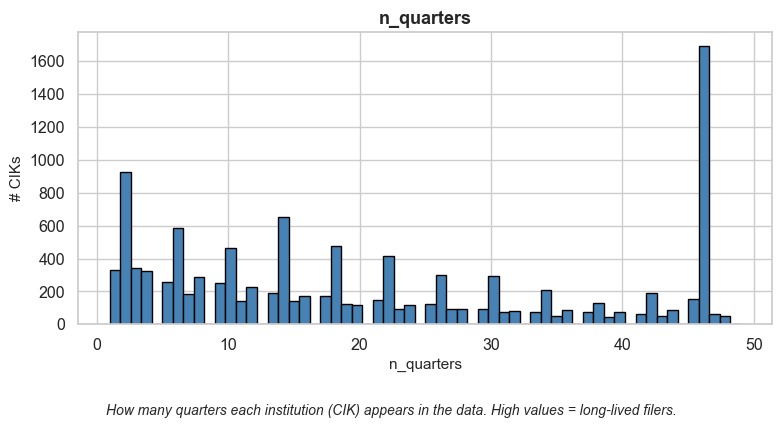

  n=11,408  |  median=18  |  mean=21.1  |  p90=46



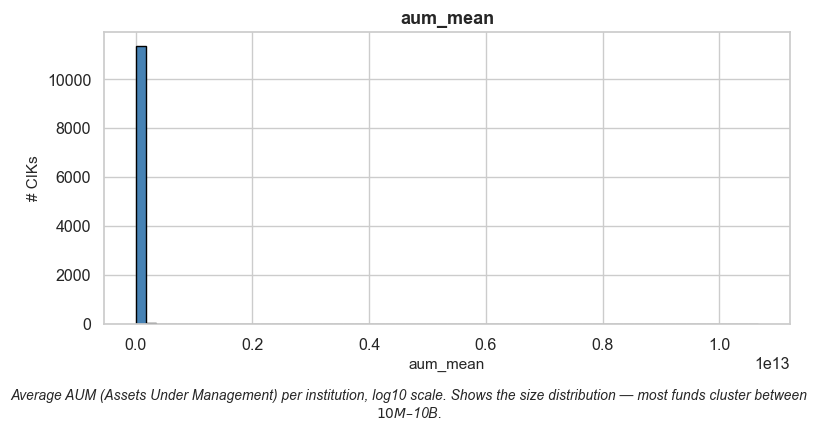

  n=11,408  |  median=1.23e+08  |  mean=5.73e+09  |  p90=2.26e+09



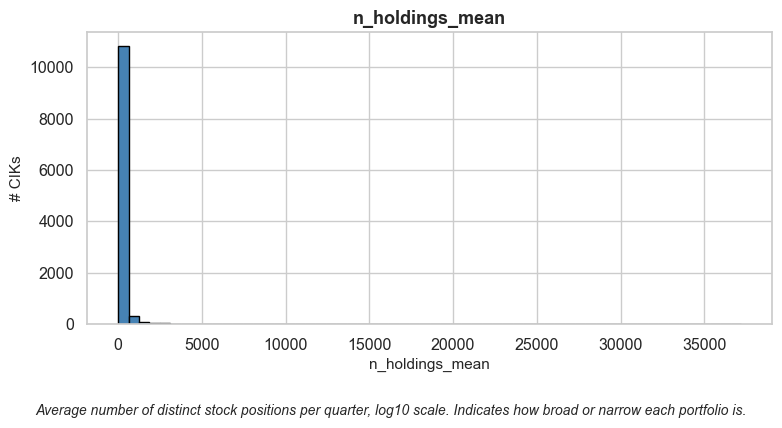

  n=11,408  |  median=47  |  mean=190  |  p90=346



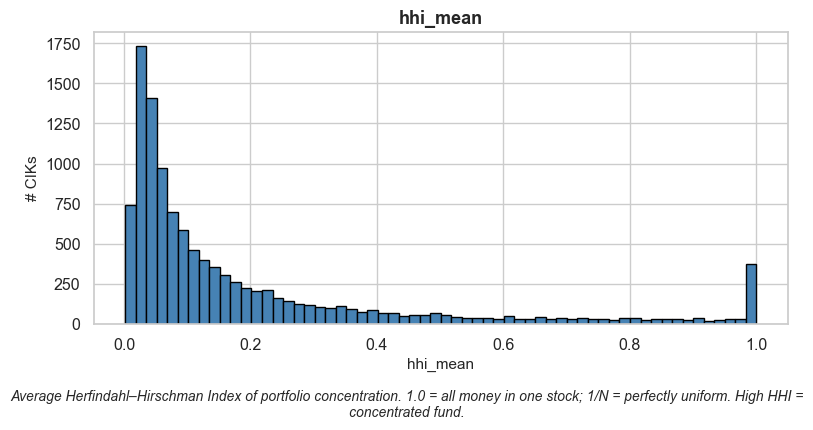

  n=11,408  |  median=0.0887  |  mean=0.198  |  p90=0.589



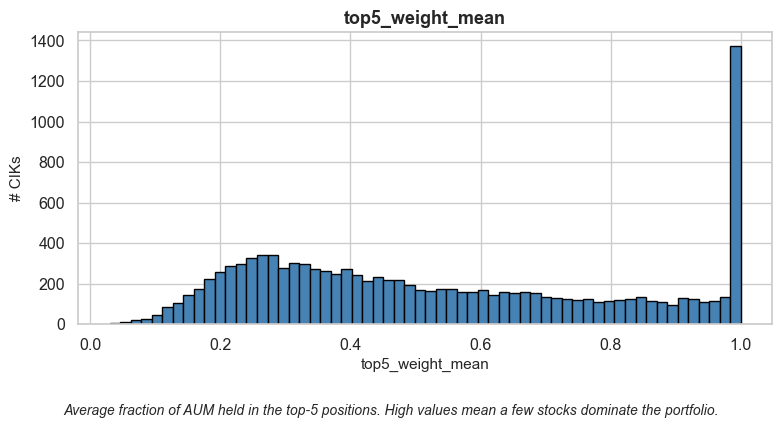

  n=11,408  |  median=0.479  |  mean=0.539  |  p90=0.998



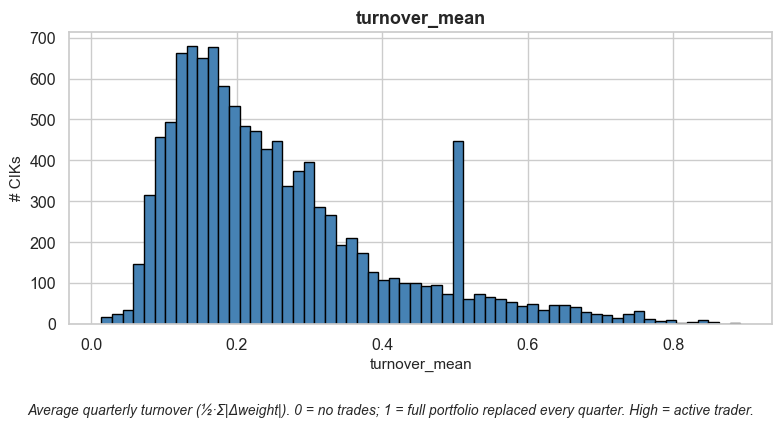

  n=11,408  |  median=0.216  |  mean=0.257  |  p90=0.5



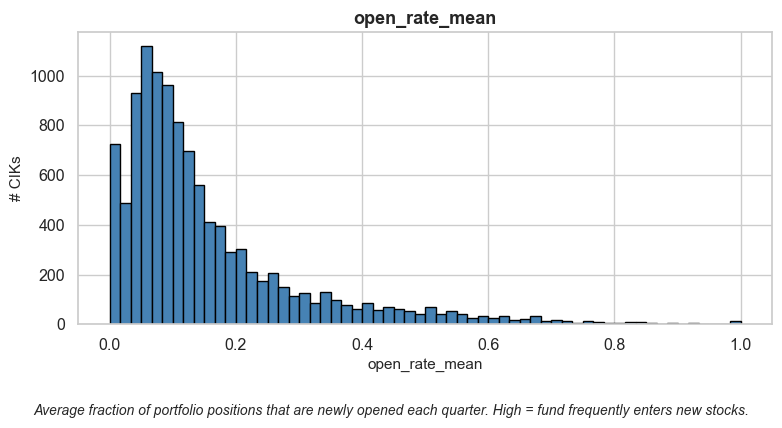

  n=11,031  |  median=0.105  |  mean=0.154  |  p90=0.355



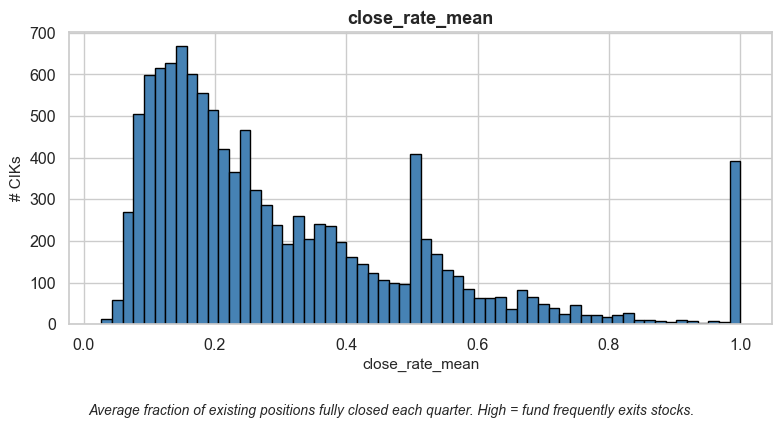

  n=11,408  |  median=0.233  |  mean=0.305  |  p90=0.587



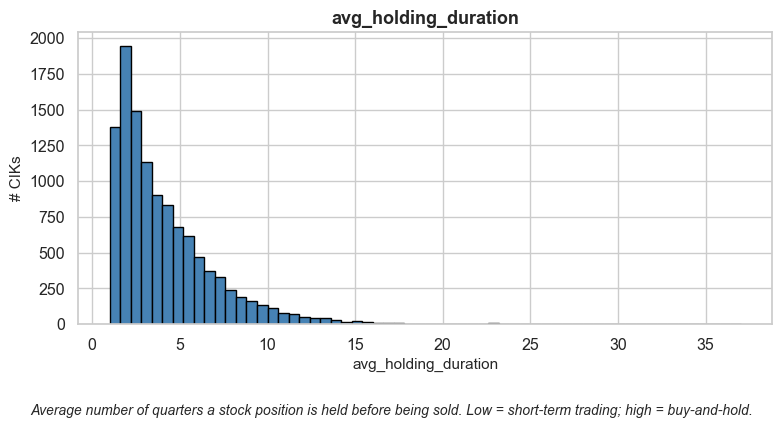

  n=11,408  |  median=3.25  |  mean=4.11  |  p90=7.87



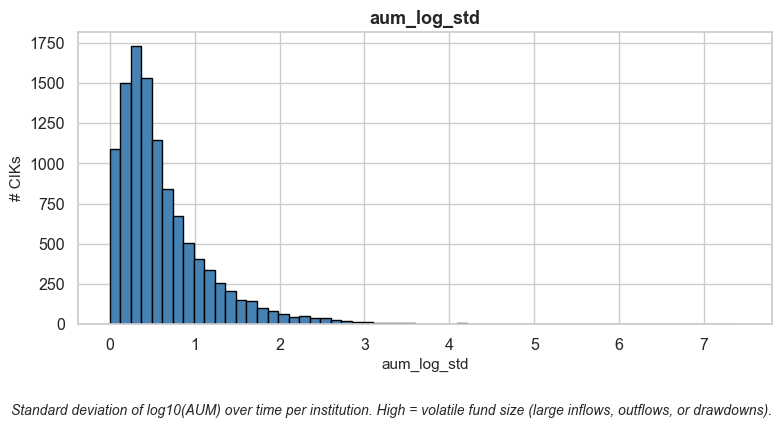

  n=11,077  |  median=0.469  |  mean=0.635  |  p90=1.34



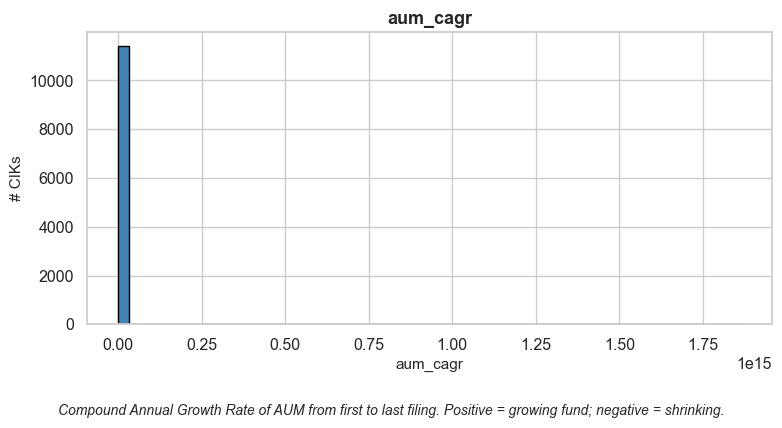

  n=11,408  |  median=0.111  |  mean=1.63e+11  |  p90=0.734

                        count          mean           std          min  \
n_quarters            11408.0  2.109002e+01  1.563256e+01     1.000000   
aum_mean              11408.0  5.726540e+09  1.262707e+11  2759.432000   
n_holdings_mean       11408.0  1.901267e+02  8.893092e+02     1.000000   
hhi_mean              11408.0  1.981975e-01  2.520539e-01     0.002029   
top5_weight_mean      11408.0  5.393921e-01  2.789861e-01     0.029899   
turnover_mean         11408.0  2.571813e-01  1.505735e-01     0.013514   
open_rate_mean        11031.0  1.541565e-01  1.507564e-01     0.000000   
close_rate_mean       11408.0  3.053561e-01  2.194172e-01     0.027027   
avg_holding_duration  11408.0  4.109515e+00  2.860201e+00     1.000000   
aum_log_std           11077.0  6.347420e-01  5.799185e-01     0.000048   
aum_cagr              11408.0  1.634167e+11  1.745406e+13    -1.000000   

                               10%           25%  

In [42]:
plot_cols = [
    "n_quarters", "aum_mean", "n_holdings_mean", "hhi_mean",
    "top5_weight_mean", "turnover_mean", "open_rate_mean",
    "close_rate_mean", "avg_holding_duration", "aum_log_std", "aum_cagr",
]
log_cols = {}
# log_cols = {"aum_mean", "n_holdings_mean"}

descriptions = {
    "n_quarters":           "How many quarters each institution (CIK) appears in the data. High values = long-lived filers.",
    "aum_mean":             "Average AUM (Assets Under Management) per institution, log10 scale. Shows the size distribution — most funds cluster between $10M–$10B.",
    "n_holdings_mean":      "Average number of distinct stock positions per quarter, log10 scale. Indicates how broad or narrow each portfolio is.",
    "hhi_mean":             "Average Herfindahl–Hirschman Index of portfolio concentration. 1.0 = all money in one stock; 1/N = perfectly uniform. High HHI = concentrated fund.",
    "top5_weight_mean":     "Average fraction of AUM held in the top-5 positions. High values mean a few stocks dominate the portfolio.",
    "turnover_mean":        "Average quarterly turnover (½·Σ|Δweight|). 0 = no trades; 1 = full portfolio replaced every quarter. High = active trader.",
    "open_rate_mean":       "Average fraction of portfolio positions that are newly opened each quarter. High = fund frequently enters new stocks.",
    "close_rate_mean":      "Average fraction of existing positions fully closed each quarter. High = fund frequently exits stocks.",
    "avg_holding_duration": "Average number of quarters a stock position is held before being sold. Low = short-term trading; high = buy-and-hold.",
    "aum_log_std":          "Standard deviation of log10(AUM) over time per institution. High = volatile fund size (large inflows, outflows, or drawdowns).",
    "aum_cagr":             "Compound Annual Growth Rate of AUM from first to last filing. Positive = growing fund; negative = shrinking.",
}

for col in plot_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    data = profile[col].dropna()
    if col in log_cols:
        data = data[data > 0]
        ax.hist(np.log10(data), bins=60, color="steelblue", edgecolor="black")
        ax.set_xlabel(f"log10({col})", fontsize=11)
    else:
        ax.hist(data, bins=60, color="steelblue", edgecolor="black")
        ax.set_xlabel(col, fontsize=11)
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_ylabel("# CIKs", fontsize=11)
    fig.text(0.5, -0.06, descriptions[col], ha="center", fontsize=10, style="italic", wrap=True)
    plt.tight_layout()
    plt.show()
    print(f"  n={data.shape[0]:,}  |  median={data.median():.3g}  |  mean={data.mean():.3g}  |  p90={data.quantile(0.9):.3g}\n")

print(profile[plot_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T)

## Archetype heuristics

Derived flags to label CIKs by behavior. Cutoffs use distribution percentiles so they adapt to the data.

In [45]:
def tag_archetypes(p: pd.DataFrame) -> pd.DataFrame:
    q = p.copy()
    turnover_low  = q["turnover_mean"].quantile(0.25)
    turnover_high = q["turnover_mean"].quantile(0.75)
    duration_long = q["avg_holding_duration"].quantile(0.75)
    churn_high    = q["open_rate_mean"].quantile(0.75)
    conc_high     = q["hhi_mean"].quantile(0.75)
    conc_low      = q["hhi_mean"].quantile(0.25)

    q["is_buy_and_hold"] = (q["turnover_mean"] <= turnover_low) & (q["avg_holding_duration"] >= duration_long)
    q["is_high_churn"]   = (q["turnover_mean"] >= turnover_high) | (q["open_rate_mean"] >= churn_high)
    q["is_concentrated"] = q["hhi_mean"] >= conc_high
    q["is_diversified"]  = q["hhi_mean"] <= conc_low
    return q

profile = tag_archetypes(profile)
profile[["is_buy_and_hold", "is_high_churn", "is_concentrated", "is_diversified"]].sum()

is_buy_and_hold    1802
is_high_churn      3598
is_concentrated    2852
is_diversified     2852
dtype: int64

## ⚙️  Filter — tune thresholds here

Set any criterion to `None` to skip it. The `filter_ciks` function returns a DataFrame of matching CIKs, ranked by AUM.

In [46]:
def filter_ciks(
    p: pd.DataFrame,
    min_quarters: int | None = 8,
    min_aum: float | None = None,
    max_aum: float | None = None,
    min_n_holdings: int | None = None,
    max_n_holdings: int | None = None,
    min_hhi: float | None = None,
    max_hhi: float | None = None,
    min_turnover: float | None = None,
    max_turnover: float | None = None,
    min_avg_duration: float | None = None,
    max_avg_duration: float | None = None,
    max_open_rate: float | None = None,
    archetype: str | None = None,  # 'buy_and_hold' | 'high_churn' | 'concentrated' | 'diversified'
) -> pd.DataFrame:
    """Return CIK profiles matching the given thresholds, sorted by AUM desc."""
    q = p.copy()
    mask = pd.Series(True, index=q.index)
    if min_quarters    is not None: mask &= q["n_quarters"]        >= min_quarters
    if min_aum         is not None: mask &= q["aum_mean"]          >= min_aum
    if max_aum         is not None: mask &= q["aum_mean"]          <= max_aum
    if min_n_holdings  is not None: mask &= q["n_holdings_mean"]   >= min_n_holdings
    if max_n_holdings  is not None: mask &= q["n_holdings_mean"]   <= max_n_holdings
    if min_hhi         is not None: mask &= q["hhi_mean"]          >= min_hhi
    if max_hhi         is not None: mask &= q["hhi_mean"]          <= max_hhi
    if min_turnover    is not None: mask &= q["turnover_mean"]     >= min_turnover
    if max_turnover    is not None: mask &= q["turnover_mean"]     <= max_turnover
    if min_avg_duration is not None: mask &= q["avg_holding_duration"] >= min_avg_duration
    if max_avg_duration is not None: mask &= q["avg_holding_duration"] <= max_avg_duration
    if max_open_rate   is not None: mask &= q["open_rate_mean"]    <= max_open_rate
    if archetype is not None:
        col = f"is_{archetype}"
        if col not in q.columns:
            raise ValueError(f"unknown archetype '{archetype}'")
        mask &= q[col]
    return q.loc[mask].sort_values("aum_mean", ascending=False).reset_index(drop=True)


# ---- Example: long-lived, medium-sized, low-turnover buy-and-hold investors ----
selected = filter_ciks(
    profile,
    min_quarters=12,
    min_aum=1e8,
    max_turnover=0.25,
    min_avg_duration=4.0,
)
print(f"matched CIKs: {len(selected):,}")
selected.head(20)

matched CIKs: 2,554


,cik,n_quarters,first_period,last_period,aum_mean,aum_median,n_holdings_mean,n_holdings_std,hhi_mean,top5_weight_mean,...,aum_cagr,turnover_mean,turnover_std,open_rate_mean,close_rate_mean,avg_holding_duration,is_buy_and_hold,is_high_churn,is_concentrated,is_diversified
0,0000093751,46,8055,8101,1.845593e+12,1.501604e+12,3173.891304,1208.415937,0.068490,0.328174,...,-0.008640,0.128219,0.138708,0.020319,0.060870,5.303462,False,False,False,False
1,0001006249,13,8055,8067,1.789720e+12,1.717588e+12,2638.615385,95.192383,0.263244,0.813760,...,0.161532,0.106809,0.133198,0.020520,0.088318,11.043786,True,False,True,False
2,0000080255,46,8055,8101,1.392885e+12,7.271668e+11,2645.586957,1014.315808,0.198086,0.429961,...,-0.153106,0.129686,0.153993,0.031139,0.067591,4.106114,False,False,False,False
3,0000913414,13,8055,8067,1.108952e+12,1.069115e+12,2610.153846,72.662285,0.133426,0.592625,...,0.053489,0.091362,0.125968,0.020928,0.090297,10.907104,True,False,False,False
4,0000814133,46,8055,8101,4.667330e+11,1.581444e+10,227.804348,37.561576,0.273746,0.396513,...,-0.342689,0.135699,0.166055,0.083689,0.126838,6.804545,True,False,True,False
5,0001128239,36,8055,8090,4.596030e+11,6.639339e+08,39.111111,7.581096,0.282206,0.659366,...,-0.656771,0.170190,0.143816,0.061963,0.092437,8.585366,False,False,True,False
6,0001422849,46,8055,8101,3.663270e+11,3.238431e+11,394.173913,83.760586,0.053621,0.245413,...,0.082291,0.170263,0.185104,0.066119,0.102795,7.748718,False,False,False,False
7,0001374170,46,8053,8101,3.343423e+11,2.434804e+11,1897.891304,776.467334,0.050003,0.224431,...,0.099498,0.134410,0.184293,0.033800,0.075586,5.540937,True,False,False,False
8,0001465837,36,8063,8098,3.219538e+11,2.058885e+09,33.750000,18.564752,0.493542,0.751125,...,0.398882,0.198512,0.250093,0.168589,0.143549,5.522727,False,False,True,False
9,0001422848,46,8055,8101,2.424190e+11,2.243065e+11,322.217391,68.289877,0.018234,0.216821,...,0.090522,0.124522,0.084996,0.062878,0.104094,7.671843,True,False,False,True


In [47]:
# Export the matching CIK list
cik_list = selected["cik"].tolist()
print(f"{len(cik_list)} CIKs")
print(cik_list[:20])

2554 CIKs
['0000093751', '0001006249', '0000080255', '0000913414', '0000814133', '0001128239', '0001422849', '0001374170', '0001465837', '0001422848', '0000884546', '0000763212', '0000887793', '0001305227', '0001562230', '0001109448', '0001085393', '0000829108', '0000906304', '0001316550']


## Quick archetype counts

In [49]:
for arch in ["buy_and_hold", "high_churn", "concentrated", "diversified"]:
    sub = filter_ciks(profile, min_quarters=8, archetype=arch)
    print(f"{arch:16s}  n={len(sub):5d}  median AUM={sub['aum_mean'].median():.2e}  median turnover={sub['turnover_mean'].median():.3f}")

buy_and_hold      n= 1781  median AUM=1.88e+08  median turnover=0.110
high_churn        n= 2103  median AUM=1.68e+08  median turnover=0.385
concentrated      n= 1918  median AUM=1.17e+08  median turnover=0.210
diversified       n= 2196  median AUM=2.86e+08  median turnover=0.144


## sweet spot defaults

### Sweet-spot search: `n_holdings_mean` threshold vs surviving #CIKs

The CIK count drops sharply as the minimum-holdings threshold rises (most filers
hold few stocks, a long tail holds thousands). The plot below shows the survival
curve, the table summarises common round thresholds and key percentiles, and
the elbow is highlighted via the second derivative on the log–log curve.



population (min_quarters=8): 8,457 CIKs


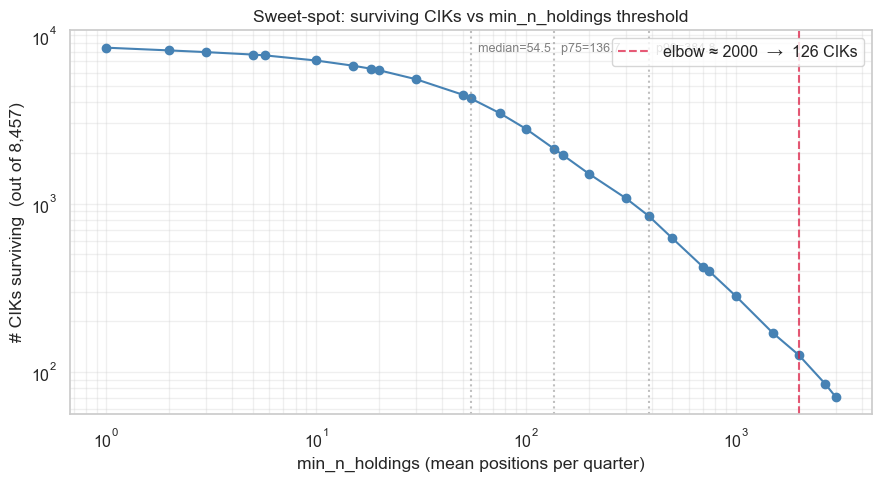


Threshold sweep:
min_n_holdings  n_ciks_surviving pct_of_population  is_elbow
           1.0              8457            100.0%     False
           2.0              8145             96.3%     False
           3.0              7958             94.1%     False
           5.0              7696             91.0%     False
           5.7              7611             90.0%     False
          10.0              7096             83.9%     False
          15.0              6611             78.2%     False
          18.2              6344             75.0%     False
          20.0              6207             73.4%     False
          30.0              5490             64.9%     False
          50.0              4445             52.6%     False
          54.5              4229             50.0%     False
          75.0              3457             40.9%     False
         100.0              2788             33.0%     False
         136.7              2115             25.0%     False
      

In [50]:
# --- Sweet-spot: how many CIKs survive each min-n_holdings threshold? --------
# Optional: combine with min_quarters so the analysis matches the population
# you'll actually train on. Set MIN_QUARTERS = None to ignore.
MIN_QUARTERS = 8

base = profile if MIN_QUARTERS is None else profile[profile["n_quarters"] >= MIN_QUARTERS]
nh = base["n_holdings_mean"].dropna().to_numpy()
n_total = len(nh)
print(f"population (min_quarters={MIN_QUARTERS}): {n_total:,} CIKs")

# Survival curve: for each unique threshold T, how many CIKs have n_holdings_mean >= T?
thresholds = np.unique(np.concatenate([
    np.array([1, 2, 3, 5, 10, 15, 20, 30, 50, 75, 100, 150, 200,
              300, 500, 750, 1000, 1500, 2000, 3000], dtype=float),
    np.quantile(nh, [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]),
]))
thresholds = thresholds[thresholds >= 1]
survivors = np.array([(nh >= t).sum() for t in thresholds])

# Elbow detection on log-log curve (max curvature ≈ max |second derivative|).
xs = np.log10(thresholds); ys = np.log10(np.maximum(survivors, 1))
d1 = np.gradient(ys, xs)
d2 = np.gradient(d1, xs)
elbow_idx = int(np.argmax(np.abs(d2)))
elbow_t   = thresholds[elbow_idx]
elbow_n   = survivors[elbow_idx]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, survivors, marker="o", color="steelblue")
ax.axvline(elbow_t, color="crimson", linestyle="--", alpha=0.7,
           label=f"elbow ≈ {elbow_t:.0f}  →  {elbow_n:,} CIKs")
for q, label in [(0.50, "median"), (0.75, "p75"), (0.90, "p90")]:
    t = np.quantile(nh, q)
    ax.axvline(t, color="gray", linestyle=":", alpha=0.5)
    ax.text(t, ax.get_ylim()[1]*0.9, f"  {label}={t:.1f}", color="gray", fontsize=9)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("min_n_holdings (mean positions per quarter)")
ax.set_ylabel(f"# CIKs surviving  (out of {n_total:,})")
ax.set_title("Sweet-spot: surviving CIKs vs min_n_holdings threshold")
ax.legend(loc="upper right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# Table
table = pd.DataFrame({
    "min_n_holdings": thresholds,
    "n_ciks_surviving": survivors,
    "pct_of_population": survivors / max(n_total, 1) * 100,
})
table["is_elbow"] = (table.index == elbow_idx)
print("\nThreshold sweep:")
print(table.to_string(index=False,
                      formatters={"min_n_holdings": "{:>7.1f}".format,
                                  "pct_of_population": "{:>5.1f}%".format}))
print(f"\nElbow (max curvature on log-log): min_n_holdings ≈ {elbow_t:.0f}  "
      f"→ {elbow_n:,} CIKs ({elbow_n/n_total*100:.1f}% of population).")



### Sweet-spot search: `max_n_holdings` threshold vs surviving #CIKs

Mirror of the `min_n_holdings` sweep but in the opposite direction — useful for
capping mega-index filers (Vanguard/BlackRock with thousands of positions) that
might dominate the graph. The plot shows how many CIKs remain as the cap rises;
the elbow is the point past which raising the cap admits very few new CIKs.



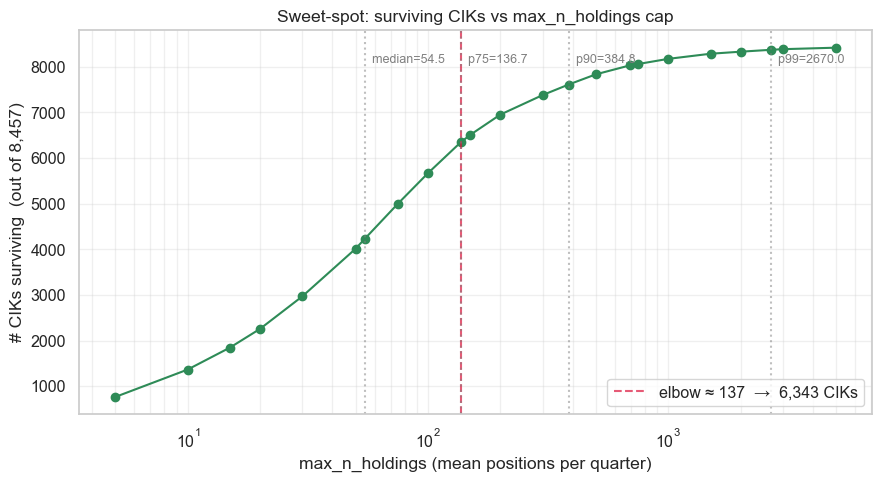


Cap sweep:
max_n_holdings  n_ciks_surviving pct_of_population  is_elbow
           5.0               766              9.1%     False
          10.0              1366             16.2%     False
          15.0              1848             21.9%     False
          20.0              2257             26.7%     False
          30.0              2970             35.1%     False
          50.0              4014             47.5%     False
          54.5              4229             50.0%     False
          75.0              5001             59.1%     False
         100.0              5669             67.0%     False
         136.7              6343             75.0%      True
         150.0              6509             77.0%     False
         200.0              6952             82.2%     False
         300.0              7380             87.3%     False
         384.8              7611             90.0%     False
         500.0              7835             92.6%     False
         695

In [51]:
# --- Sweet-spot: how many CIKs survive each max-n_holdings threshold? --------
# Reuses MIN_QUARTERS / base / nh / n_total from the previous (min) sweep cell
# if available; otherwise rebuilds them.
try:
    base, nh, n_total, MIN_QUARTERS  # noqa: F821 — defined in prior cell
except NameError:
    MIN_QUARTERS = 8
    base = profile if MIN_QUARTERS is None else profile[profile["n_quarters"] >= MIN_QUARTERS]
    nh = base["n_holdings_mean"].dropna().to_numpy()
    n_total = len(nh)
    print(f"population (min_quarters={MIN_QUARTERS}): {n_total:,} CIKs")

# Survival curve: for each cap C, how many CIKs have n_holdings_mean <= C?
caps = np.unique(np.concatenate([
    np.array([5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500,
              750, 1000, 1500, 2000, 3000, 5000], dtype=float),
    np.quantile(nh, [0.50, 0.75, 0.90, 0.95, 0.99]),
]))
caps = caps[caps >= 1]
survivors = np.array([(nh <= c).sum() for c in caps])

# Elbow detection — most curvature on log-log (here as caps grow, survivors
# asymptote to n_total, so the elbow marks "diminishing returns").
xs = np.log10(caps); ys = np.log10(np.maximum(survivors, 1))
d1 = np.gradient(ys, xs)
d2 = np.gradient(d1, xs)
elbow_idx = int(np.argmax(np.abs(d2)))
elbow_c   = caps[elbow_idx]
elbow_n   = survivors[elbow_idx]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(caps, survivors, marker="o", color="seagreen")
ax.axvline(elbow_c, color="crimson", linestyle="--", alpha=0.7,
           label=f"elbow ≈ {elbow_c:.0f}  →  {elbow_n:,} CIKs")
for q, label in [(0.50, "median"), (0.75, "p75"), (0.90, "p90"), (0.99, "p99")]:
    c = np.quantile(nh, q)
    ax.axvline(c, color="gray", linestyle=":", alpha=0.5)
    ax.text(c, ax.get_ylim()[1]*0.92, f"  {label}={c:.1f}",
            color="gray", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("max_n_holdings (mean positions per quarter)")
ax.set_ylabel(f"# CIKs surviving  (out of {n_total:,})")
ax.set_title("Sweet-spot: surviving CIKs vs max_n_holdings cap")
ax.legend(loc="lower right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# Table
table = pd.DataFrame({
    "max_n_holdings": caps,
    "n_ciks_surviving": survivors,
    "pct_of_population": survivors / max(n_total, 1) * 100,
})
table["is_elbow"] = (table.index == elbow_idx)
print("\nCap sweep:")
print(table.to_string(index=False,
                      formatters={"max_n_holdings": "{:>7.1f}".format,
                                  "pct_of_population": "{:>5.1f}%".format}))
print(f"\nElbow (max curvature on log axis): max_n_holdings ≈ {elbow_c:.0f}  "
      f"→ {elbow_n:,} CIKs ({elbow_n/n_total*100:.1f}% of population).")
print(f"Excludes ~{n_total - elbow_n:,} CIKs above the cap.")